# Portfolio Allocation Backtest

This notebook compares several portfolio allocation strategies in an out-of-sample backtest.

Two implementations are evaluated:

- **Raw portfolios:** strategies are used at their natural risk level.
- **Volatility-targeted portfolios:** exposures are scaled toward a 10% annual volatility target.

The backtest includes transaction costs, risk-free cash returns, leverage constraints and borrowing costs.

In [6]:
import sys
sys.path.append("../src")

import importlib
import pandas as pd
import matplotlib.pyplot as plt

import metrics
import allocations
import backtesting

importlib.reload(metrics)
importlib.reload(allocations)
importlib.reload(backtesting)

WINDOW = 3 * 252
STEP = 21
TRANSACTION_COST = 0.001
VOL_TARGET = 0.10
MAX_LEVERAGE = 2.0
FUNDING_SPREAD = 0.01

## Data and strategy universe

Daily ETF prices are converted into returns. The risk-free rate is converted from an annual percentage rate to a daily return and aligned with ETF trading dates.

The strategy universe combines simple benchmarks, risk-based allocations and optimization-based portfolios.

In [7]:
prices = pd.read_csv("../data/etf_prices_raw.csv", index_col="Date", parse_dates=True)
returns = metrics.compute_returns(prices)

rf_rate = pd.read_csv("../data/risk_free_rate.csv", index_col="Date", parse_dates=True)["risk_free_rate"]
rf_rate = pd.to_numeric(rf_rate, errors="coerce").ffill()

annual_rf = rf_rate / 100
risk_free_returns = (1 + annual_rf) ** (1 / 252) - 1
risk_free_returns = risk_free_returns.reindex(returns.index).ffill()

groups = {
    "equities": ["SPY", "QQQ", "EWU", "EZU", "EEM"],
    "bonds": ["IEF", "SHY"],
    "alternatives": ["GLD", "VNQ"]
}

strategies = {
    "Equal Weight": (backtesting.equal_strategy, None),
    "Inverse Vol": (backtesting.risk_strategy, None),
    "Max Geo": (backtesting.max_geo_strategy, None),
    "Max Sharpe": (backtesting.max_sharpe_strategy, None),
    "Carver": (backtesting.carver_handcrafting_strategy, groups),
    "Hierarchical Inv Vol": (backtesting.inv_handcrafting_strategy, groups),
    "SPY": (backtesting.spy_strategy, None),
    "60/40": (backtesting.sixty_forty_strategy, None),
    "Tech": (backtesting.tech_strategy, None)
}

In [8]:
def performance_summary(port_ret):
    return pd.Series({
        "Annual Return": metrics.annualize_returns(port_ret),
        "Annual Volatility": metrics.annualize_volatility(port_ret),
        "Sharpe Ratio": metrics.sharpe_ratio(port_ret, risk_free_returns),
        "Drawdown": metrics.drawdown(port_ret)
    })

def leverage_summary(leverage):
    return pd.Series({
        "Average Leverage": leverage.mean(),
        "Max Leverage": leverage.max(),
        "Min Leverage": leverage.min(),
        "Time at 2x": (leverage >= 2.0 - 1e-10).mean()
    })

def turnover_summary(turnover):
    return pd.Series({
        "Average Turnover": turnover.mean(),
        "Max Turnover": turnover.max()
    })

def transaction_cost_summary(costs):
    return pd.Series({
        "Total Cost": costs.sum(),
        "Average Cost per Rebalance": costs.mean(),
        "Max Cost per Rebalance": costs.max()
    })

## Raw portfolios

The first backtest evaluates each strategy without volatility targeting.

Transaction costs are applied at each rebalance. Any uninvested cash earns the risk-free rate.

In [9]:
raw_portfolio_returns = {}
raw_weight_histories = {}
raw_turnover_histories = {}
raw_transaction_cost_histories = {}

for name, (strategy, strategy_groups) in strategies.items():
    port_ret, weights, _, turnover, transaction_cost = backtesting.backtest(
        returns,
        window=WINDOW,
        step=STEP,
        allocation_func=strategy,
        groups=strategy_groups,
        vol_target=None,
        risk_free_returns=risk_free_returns,
        transaction_cost=TRANSACTION_COST,
        funding_spread=FUNDING_SPREAD
    )

    raw_portfolio_returns[name] = port_ret
    raw_weight_histories[name] = weights
    raw_turnover_histories[name] = turnover
    raw_transaction_cost_histories[name] = transaction_cost

raw_summary = pd.DataFrame({
    name: performance_summary(port_ret)
    for name, port_ret in raw_portfolio_returns.items()
}).T

raw_turnover_summary = pd.DataFrame({
    name: turnover_summary(turnover)
    for name, turnover in raw_turnover_histories.items()
}).T

raw_transaction_cost_summary = pd.DataFrame({
    name: transaction_cost_summary(costs)
    for name, costs in raw_transaction_cost_histories.items()
}).T

display(
    raw_summary.style
    .format({
        "Annual Return": "{:.2%}",
        "Annual Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Drawdown": "{:.2%}"
    })
    .set_caption("Raw Portfolio Performance")
)

display(
    raw_turnover_summary.style
    .format({
        "Average Turnover": "{:.2%}",
        "Max Turnover": "{:.2%}"
    })
    .set_caption("Raw Portfolio Turnover")
)

display(
    raw_transaction_cost_summary.style
    .format({
        "Total Cost": "{:.2%}",
        "Average Cost per Rebalance": "{:.4%}",
        "Max Cost per Rebalance": "{:.4%}"
    })
    .set_caption("Raw Portfolio Transaction Costs")
)

,Annual Return,Annual Volatility,Sharpe Ratio,Drawdown
Equal Weight,7.31%,14.60%,0.459,-41.61%
Inverse Vol,3.77%,4.94%,0.486,-15.47%
Max Geo,11.28%,16.22%,0.653,-39.34%
Max Sharpe,6.56%,9.06%,0.590,-24.99%
Carver,3.17%,3.38%,0.521,-10.07%
Hierarchical Inv Vol,3.33%,3.69%,0.521,-10.25%
SPY,11.40%,19.74%,0.574,-51.48%
60/40,8.28%,11.11%,0.643,-31.48%
Tech,16.43%,22.41%,0.728,-49.37%


,Average Turnover,Max Turnover
Equal Weight,1.36%,5.43%
Inverse Vol,0.94%,5.60%
Max Geo,8.25%,41.38%
Max Sharpe,11.70%,85.40%
Carver,0.72%,4.81%
Hierarchical Inv Vol,0.78%,5.33%
SPY,0.00%,0.00%
60/40,0.98%,5.39%
Tech,0.00%,0.00%


,Total Cost,Average Cost per Rebalance,Max Cost per Rebalance
Equal Weight,0.61%,0.0027%,0.0109%
Inverse Vol,0.42%,0.0019%,0.0112%
Max Geo,3.71%,0.0165%,0.0828%
Max Sharpe,5.27%,0.0234%,0.1708%
Carver,0.33%,0.0014%,0.0096%
Hierarchical Inv Vol,0.35%,0.0016%,0.0107%
SPY,0.00%,0.0000%,0.0000%
60/40,0.44%,0.0020%,0.0108%
Tech,0.00%,0.0000%,0.0000%


## Volatility-targeted portfolios

Portfolio exposures are scaled toward a **10% annual volatility target**.

Leverage is capped at **2x**. Positive cash earns the risk-free rate, while borrowed capital pays the risk-free rate plus a **1% annual funding spread**.

In [10]:
targeted_portfolio_returns = {}
targeted_weight_histories = {}
targeted_leverage_histories = {}
targeted_turnover_histories = {}
targeted_transaction_cost_histories = {}

for name, (strategy, strategy_groups) in strategies.items():
    port_ret, weights, leverage, turnover, transaction_cost = backtesting.backtest(
        returns,
        window=WINDOW,
        step=STEP,
        allocation_func=strategy,
        groups=strategy_groups,
        vol_target=VOL_TARGET,
        max_leverage=MAX_LEVERAGE,
        risk_free_returns=risk_free_returns,
        transaction_cost=TRANSACTION_COST,
        funding_spread=FUNDING_SPREAD
    )

    targeted_portfolio_returns[name] = port_ret
    targeted_weight_histories[name] = weights
    targeted_leverage_histories[name] = leverage
    targeted_turnover_histories[name] = turnover
    targeted_transaction_cost_histories[name] = transaction_cost

targeted_summary = pd.DataFrame({
    name: performance_summary(port_ret)
    for name, port_ret in targeted_portfolio_returns.items()
}).T

targeted_leverage_summary = pd.DataFrame({
    name: leverage_summary(leverage)
    for name, leverage in targeted_leverage_histories.items()
}).T

targeted_turnover_summary = pd.DataFrame({
    name: turnover_summary(turnover)
    for name, turnover in targeted_turnover_histories.items()
}).T

targeted_transaction_cost_summary = pd.DataFrame({
    name: transaction_cost_summary(costs)
    for name, costs in targeted_transaction_cost_histories.items()
}).T

display(
    targeted_summary.style
    .format({
        "Annual Return": "{:.2%}",
        "Annual Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Drawdown": "{:.2%}"
    })
    .set_caption("Volatility-Targeted Portfolio Performance")
)

display(
    targeted_leverage_summary.style
    .format({
        "Average Leverage": "{:.2f}x",
        "Max Leverage": "{:.2f}x",
        "Min Leverage": "{:.2f}x",
        "Time at 2x": "{:.2%}"
    })
    .set_caption("Volatility-Targeted Leverage")
)

display(
    targeted_turnover_summary.style
    .format({
        "Average Turnover": "{:.2%}",
        "Max Turnover": "{:.2%}"
    })
    .set_caption("Volatility-Targeted Turnover")
)

display(
    targeted_transaction_cost_summary.style
    .format({
        "Total Cost": "{:.2%}",
        "Average Cost per Rebalance": "{:.4%}",
        "Max Cost per Rebalance": "{:.4%}"
    })
    .set_caption("Volatility-Targeted Transaction Costs")
)

,Annual Return,Annual Volatility,Sharpe Ratio,Drawdown
Equal Weight,5.23%,10.86%,0.393,-30.50%
Inverse Vol,4.06%,9.01%,0.329,-29.73%
Max Geo,8.03%,10.57%,0.650,-24.03%
Max Sharpe,6.72%,8.40%,0.648,-22.58%
Carver,3.76%,6.73%,0.371,-21.25%
Hierarchical Inv Vol,4.00%,7.30%,0.379,-21.59%
SPY,6.63%,11.06%,0.507,-30.91%
60/40,7.41%,11.11%,0.571,-31.05%
Tech,8.47%,10.64%,0.683,-26.99%


,Average Leverage,Max Leverage,Min Leverage,Time at 2x
Equal Weight,0.80x,1.27x,0.39x,0.00%
Inverse Vol,1.84x,2.00x,1.43x,60.89%
Max Geo,0.63x,0.94x,0.36x,0.00%
Max Sharpe,1.60x,2.00x,0.51x,60.00%
Carver,1.99x,2.00x,1.85x,91.11%
Hierarchical Inv Vol,1.98x,2.00x,1.76x,88.44%
SPY,0.58x,0.88x,0.33x,0.00%
60/40,1.02x,1.54x,0.58x,0.00%
Tech,0.49x,0.75x,0.33x,0.00%


,Average Turnover,Max Turnover
Equal Weight,1.38%,18.15%
Inverse Vol,2.26%,17.26%
Max Geo,5.80%,34.93%
Max Sharpe,16.81%,130.91%
Carver,1.81%,9.03%
Hierarchical Inv Vol,1.95%,10.10%
SPY,0.68%,8.42%
60/40,1.48%,16.91%
Tech,0.60%,4.80%


,Total Cost,Average Cost per Rebalance,Max Cost per Rebalance
Equal Weight,0.62%,0.0028%,0.0363%
Inverse Vol,1.02%,0.0045%,0.0345%
Max Geo,2.61%,0.0116%,0.0699%
Max Sharpe,7.56%,0.0336%,0.2618%
Carver,0.81%,0.0036%,0.0181%
Hierarchical Inv Vol,0.88%,0.0039%,0.0202%
SPY,0.31%,0.0014%,0.0168%
60/40,0.67%,0.0030%,0.0338%
Tech,0.27%,0.0012%,0.0096%


## Portfolio paths

The following figures compare cumulative portfolio growth for the raw and volatility-targeted implementations, followed by drawdown paths for a representative subset of strategies.

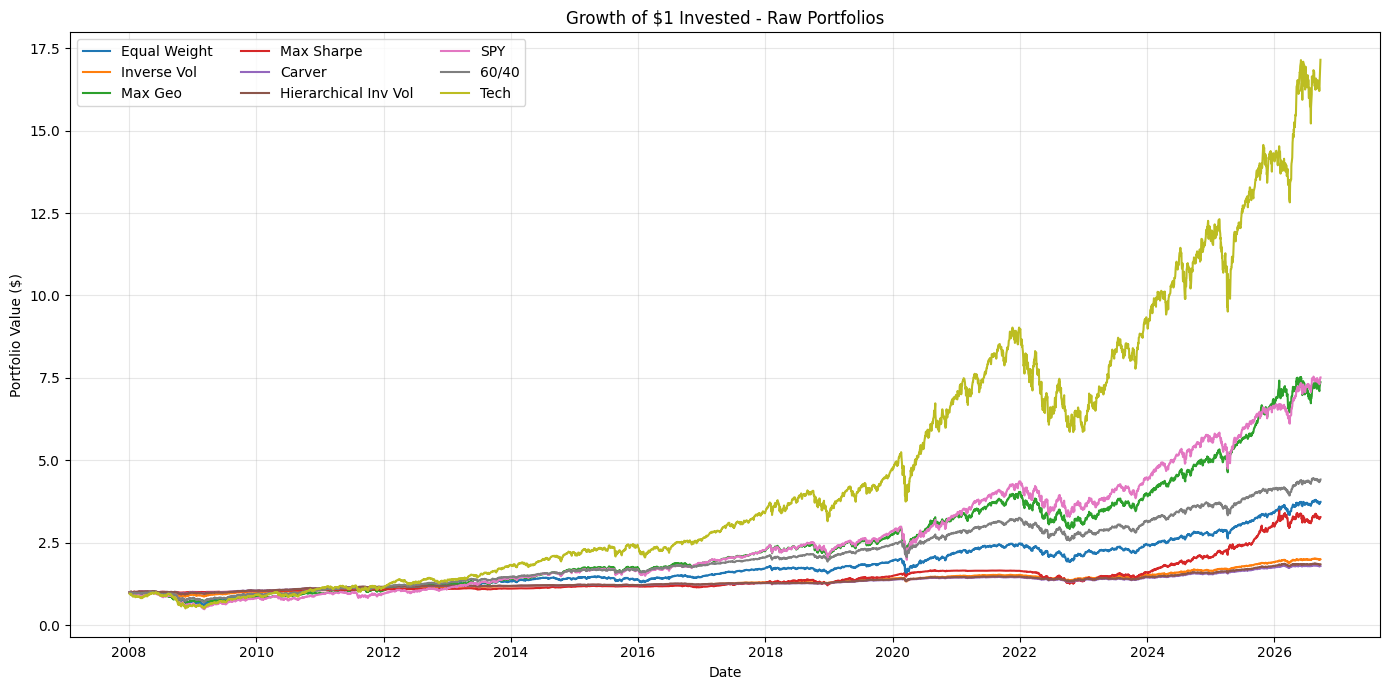

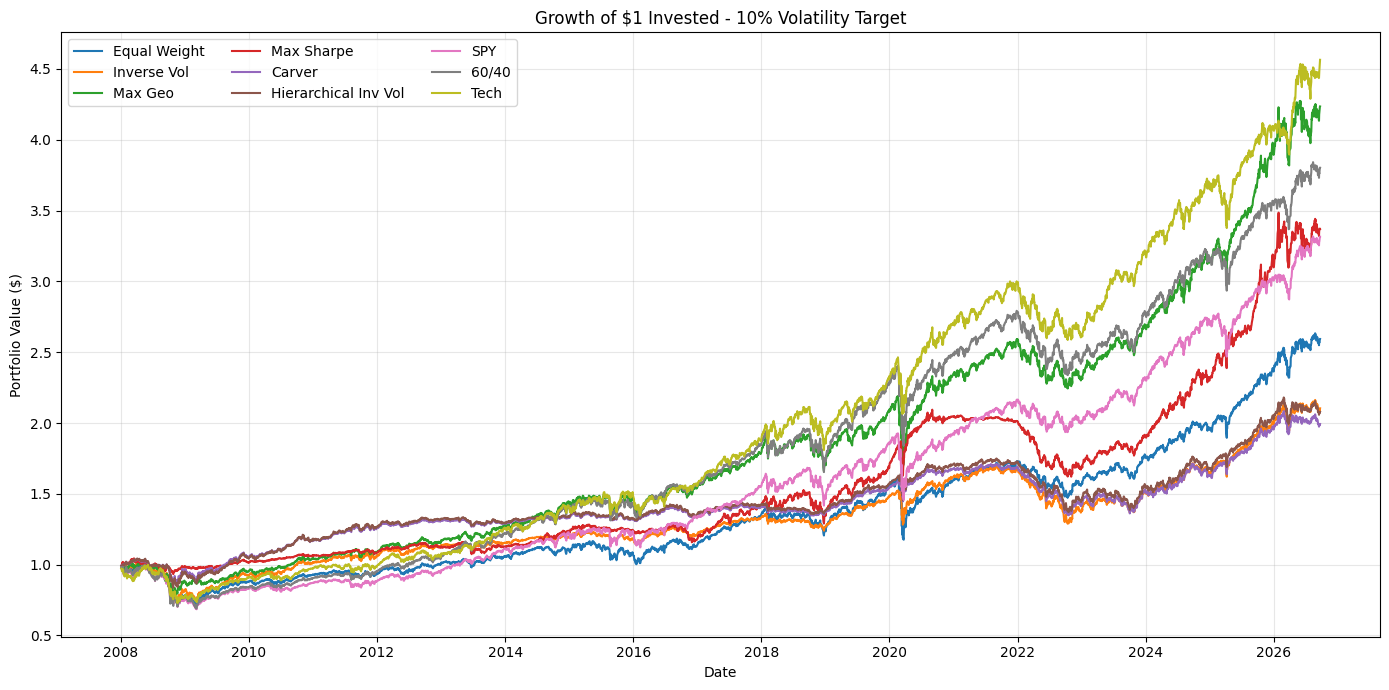

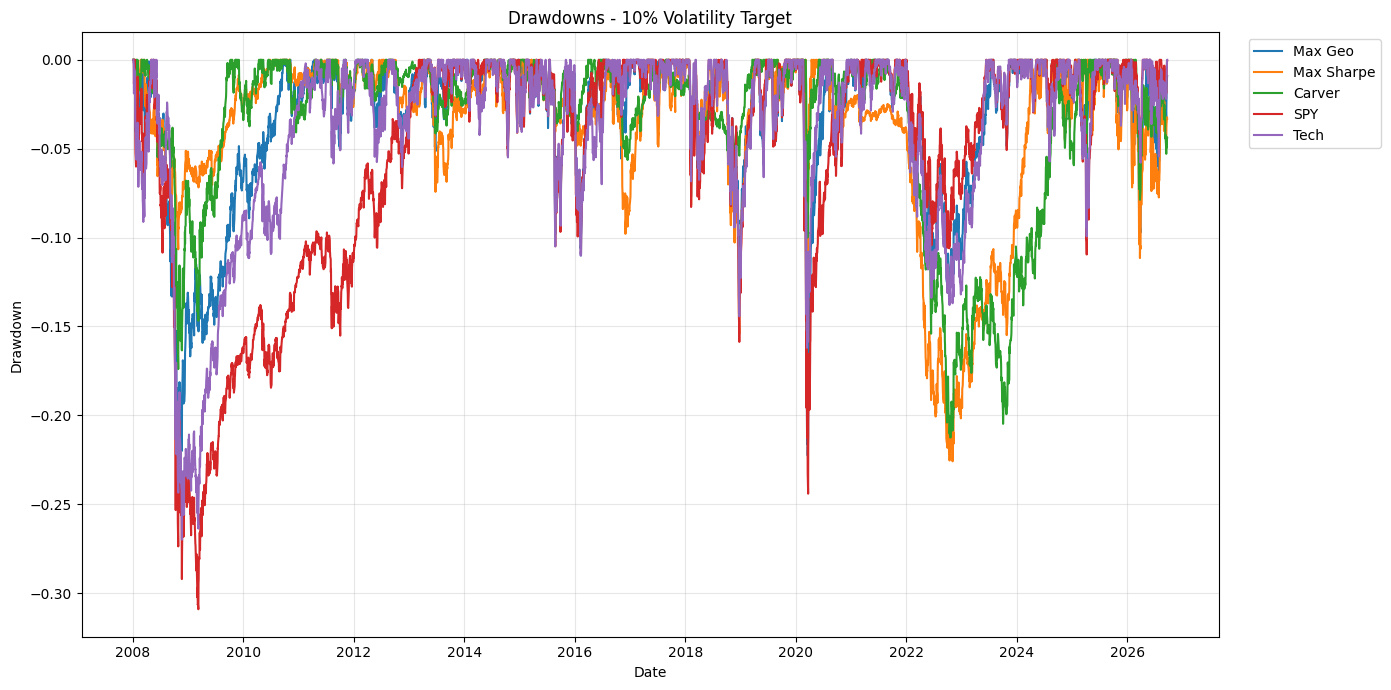

In [11]:
raw_returns_ts = pd.DataFrame(raw_portfolio_returns)
targeted_returns_ts = pd.DataFrame(targeted_portfolio_returns)

raw_wealth = (1 + raw_returns_ts).cumprod()
targeted_wealth = (1 + targeted_returns_ts).cumprod()

plt.figure(figsize=(14, 7))

for strategy in raw_wealth.columns:
    plt.plot(raw_wealth.index, raw_wealth[strategy], label=strategy)

plt.title("Growth of $1 Invested - Raw Portfolios")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend(ncol=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 7))

for strategy in targeted_wealth.columns:
    plt.plot(targeted_wealth.index, targeted_wealth[strategy], label=strategy)

plt.title("Growth of $1 Invested - 10% Volatility Target")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend(ncol=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

selected = ["Max Geo", "Max Sharpe", "Carver", "SPY", "Tech"]

targeted_drawdown = targeted_wealth[selected] / targeted_wealth[selected].cummax() - 1

plt.figure(figsize=(14, 7))

for strategy in selected:
    plt.plot(targeted_drawdown.index, targeted_drawdown[strategy], label=strategy)

plt.title("Drawdowns - 10% Volatility Target")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()